<a href="https://colab.research.google.com/github/Psalmist70/sms-phishing-detection/blob/main/notebooks/sms-phishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = '/content/drive/MyDrive/sms-phishing-detection/dataset'

RAW_PATH = f'{BASE_PATH}/raw'
CLEANED_PATH = f'{BASE_PATH}/cleaned'

In [ ]:
import pandas as pd

file_path = f'{RAW_PATH}/sms_spam.csv'  # change this

df = pd.read_csv(file_path, encoding="latin1")
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# 👉 CHANGE THESE based on your dataset
label_col = 'label'       # e.g. 'label', 'v1'
message_col = 'message'     # e.g. 'message', 'text'

df = df[[label_col, message_col]]
df.columns = ['label', 'message']

In [ ]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['label'] = df['label'].astype(str).str.lower().str.strip()

df['label'] = df['label'].replace({
    'spam': 1,
    'ham': 0,
    'smishing': 1,
    'legitimate': 0,
    '1': 1,
    '0': 0
})

df['label'] = df['label'].astype(int)

/tmp/ipykernel_26550/953889016.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({


In [ ]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()

    # Replace URLs with token (important for phishing detection)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

df['message'] = df['message'].apply(clean_text)

In [ ]:
print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


In [ ]:
df['source'] = 'kaggle'  # change per dataset

In [ ]:
df.head()

,label,message,source
0,0,"go until jurong point, crazy.. available only ...",kaggle
1,0,ok lar... joking wif u oni...,kaggle
2,1,free entry in 2 a wkly comp to win fa cup fina...,kaggle
3,0,u dun say so early hor... u c already then say...,kaggle
4,0,"nah i don't think he goes to usf, he lives aro...",kaggle


In [ ]:
output_path = f'{CLEANED_PATH}/kaggle_sms_cleaned_v1.csv'

df.to_csv(output_path, index=False)

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   int64 
 1   message  5572 non-null   object
 2   source   5572 non-null   object
dtypes: int64(1), object(2)
memory usage: 130.7+ KB


,label,message,source
0,0,"go until jurong point, crazy.. available only ...",kaggle
1,0,ok lar... joking wif u oni...,kaggle
2,1,free entry in 2 a wkly comp to win fa cup fina...,kaggle
3,0,u dun say so early hor... u c already then say...,kaggle
4,0,"nah i don't think he goes to usf, he lives aro...",kaggle


In [ ]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import re

# ================================
# 2. LOAD DATA (NO HEADERS)
# ================================
file_path = f'{RAW_PATH}/USER 20.csv'  # change filename

df = pd.read_csv(file_path, encoding="latin1", header=None)

# Preview
print(df.head())
print(df.shape)

# ================================
# 3. SELECT REQUIRED COLUMNS (6 & 7 → index 5 & 6)
# ================================
df = df[[6, 7]]

# Rename columns
df.columns = ['label', 'message']

# ================================
# 4. CLEAN & STANDARDIZE LABELS
# ================================
df['label'] = df['label'].astype(str).str.lower().str.strip()

df['label'] = df['label'].replace({
    'spam': 1,
    'ham': 0,
    'phishing': 1,
    'legitimate': 0,
    '1': 1,
    '0': 0
})

# Drop rows where label couldn't be mapped
df = df[df['label'].isin([0, 1])]

df['label'] = df['label'].astype(int)

# ================================
# 5. CLEAN TEXT (KEEP IMPORTANT SIGNALS)
# ================================
def clean_text(text):
    text = str(text).lower()

    # Replace URLs with token
    text = re.sub(r'http\S+|www\S+', ' URL ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

df['message'] = df['message'].apply(clean_text)

# ================================
# 6. REMOVE DUPLICATES
# ================================
df = df.drop_duplicates(subset='message')

# ================================
# 7. CHECK CLASS DISTRIBUTION
# ================================
print("Class distribution:")
print(df['label'].value_counts())

# ================================
# 8. ADD SOURCE COLUMN
# ================================
df['source'] = 'kaggle'  # change depending on dataset

# ================================
# 9. SAVE CLEANED (UNBALANCED)
# ================================
output_path = f'{CLEANED_PATH}/user20_sms_cleaned_v1.csv'

df.to_csv(output_path, index=False)

print("Saved successfully!")

    0        1           2           3                 4   5     6   \
0  SMS     send  7055454446  7055454446  28/02/2016 16:04   9   HAM   
1  SMS  receive        4100        4100  28/02/2016 16:02   8  SPAM   
2  SMS  receive        5900        5900  28/02/2016 09:36   7  SPAM   
3  SMS  receive        MTNN        MTNN  27/02/2016 15:32   6  SPAM   
4  SMS  receive       MTN N       MTN N  27/02/2016 15:30   1  SPAM   

                                                  7   \
0  Greetings ma, I know you are kind hearted, plz...   
1  Get "Ari Belema" as your Callertune. Text 3 to...   
2                              95% OFF! With just N5   
3                                           Yâello   
4  Your recharge of NGN100.00 was successful. You...   

                                                  8    9    10  
0                                                NaN  NaN  NaN  
1                                                NaN  NaN  NaN  
2   download 2HD songs & stream unlimited

/tmp/ipykernel_26550/1179069207.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({


In [ ]:
df.head()

,label,message,source
0,1,shed that unwanted weight effortlessly! text w...,kaggle
1,1,last invitation for 8037202112!today 02/09'cen...,kaggle
2,1,change is not a threat its an opportunity. tra...,kaggle
3,1,a health tip a day keeps the doctor away! to f...,kaggle
4,1,ke your money work for you. want to know how t...,kaggle


In [ ]:
import pandas as pd

BASE_PATH = '/content/drive/MyDrive/sms-phishing-detection/dataset'

CLEANED_PATH = f'{BASE_PATH}/cleaned'
FINAL_PATH = f'{BASE_PATH}/final'

In [ ]:
core = pd.read_csv(f'{CLEANED_PATH}/core_sms_cleaned_v1.csv')
kaggle = pd.read_csv(f'{CLEANED_PATH}/kaggle_sms_cleaned_v1.csv')

In [ ]:
print(core.columns)
print(kaggle.columns)

Index(['label', 'message', 'source'], dtype='object')
Index(['label', 'message', 'source'], dtype='object')


In [ ]:
df = pd.concat([core, kaggle], ignore_index=True)

In [ ]:
df = df.drop_duplicates(subset='message')

In [ ]:
print("Total samples:", len(df))

Total samples: 5555


In [ ]:
print("\nClass distribution:")
print(df['label'].value_counts())


Class distribution:
label
0    4715
1     840
Name: count, dtype: int64


In [ ]:
print("\nSource distribution:")
print(df['source'].value_counts())


Source distribution:
source
kaggle    5156
core       399
Name: count, dtype: int64


In [ ]:
output_path = f'{FINAL_PATH}/final_dataset_unbalanced_v1.csv'

df.to_csv(output_path, index=False)

print("Final dataset saved!")

Final dataset saved!


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
BASE_PATH = '/content/drive/MyDrive/sms-phishing-detection/dataset'

RAW_PATH = f'{BASE_PATH}/final'
CLEANED_PATH = f'{BASE_PATH}/cleaned'


In [6]:
import pandas as pd

file_path = f'{RAW_PATH}/final_dataset_unbalanced_v1.csv'  # change this

df = pd.read_csv(file_path, encoding="latin1")
df.head()

,label,message,source
0,0,"debit amt:ngn50,000.00 acc:171******903 desc:5...",core
1,0,"credit amt:ngn10,000.00 acc:171******903 desc:...",core
2,0,"debit amt:ngn3,000.00 acc:171******903 desc:51...",core
3,0,"debit amt:ngn2,000.00 acc:171******903 desc:51...",core
4,0,"debit amt:ngn3,000.00 acc:171******903 desc:51...",core


In [7]:
!pip install nltk

In [14]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
print(df.head())
print(df.info())

   label                                            message source
0      0  debit amt:ngn50,000.00 acc:171******903 desc:5...   core
1      0  credit amt:ngn10,000.00 acc:171******903 desc:...   core
2      0  debit amt:ngn3,000.00 acc:171******903 desc:51...   core
3      0  debit amt:ngn2,000.00 acc:171******903 desc:51...   core
4      0  debit amt:ngn3,000.00 acc:171******903 desc:51...   core
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5555 entries, 0 to 5554
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5555 non-null   int64 
 1   message  5555 non-null   object
 2   source   5555 non-null   object
dtypes: int64(1), object(2)
memory usage: 130.3+ KB
None


In [10]:
df.drop_duplicates(inplace=True)

In [11]:
print(df.head())
print(df.info())

   label                                            message source
0      0  debit amt:ngn50,000.00 acc:171******903 desc:5...   core
1      0  credit amt:ngn10,000.00 acc:171******903 desc:...   core
2      0  debit amt:ngn3,000.00 acc:171******903 desc:51...   core
3      0  debit amt:ngn2,000.00 acc:171******903 desc:51...   core
4      0  debit amt:ngn3,000.00 acc:171******903 desc:51...   core
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5555 entries, 0 to 5554
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5555 non-null   int64 
 1   message  5555 non-null   object
 2   source   5555 non-null   object
dtypes: int64(1), object(2)
memory usage: 130.3+ KB
None


In [12]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['cleaned_text'] = df['message'].apply(clean_text)


In [15]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['cleaned_text'].apply(word_tokenize)

In [16]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

In [17]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

In [18]:
df['processed_text'] = df['tokens'].apply(lambda x: " ".join(x))

In [19]:
df['label'].value_counts()

,count
label,
0,4715
1,840


In [20]:
df.to_csv('preprocess.csv', index=False)

In [22]:
# Data handling
import pandas as pd
import numpy as np

# NLP
import re
import nltk

# Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Save objects
import joblib

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [64]:
import pandas as pd

file_path = f'{RAW_PATH}/preprocess.csv'  # change this

df = pd.read_csv(file_path, encoding="latin1")
df.head()

,label,message,source,cleaned_text,tokens,processed_text
0,0,"debit amt:ngn50,000.00 acc:171******903 desc:5...",core,debit amtngn acc descamuptrffrm oluwasegun sam...,"['debit', 'amtngn', 'acc', 'descamuptrffrm', '...",debit amtngn acc descamuptrffrm oluwasegun sam...
1,0,"credit amt:ngn10,000.00 acc:171******903 desc:...",core,credit amtngn acc deschabrilfrom pastor paul o...,"['credit', 'amtngn', 'acc', 'deschabrilfrom', ...",credit amtngn acc deschabrilfrom pastor paul o...
2,0,"debit amt:ngn3,000.00 acc:171******903 desc:51...",core,debit amtngn acc descamniprmobile trf to opt x...,"['debit', 'amtngn', 'acc', 'descamniprmobile',...",debit amtngn acc descamniprmobile trf opt xpre...
3,0,"debit amt:ngn2,000.00 acc:171******903 desc:51...",core,debit amtngn acc descamnidmobile trf to opt xp...,"['debit', 'amtngn', 'acc', 'descamnidmobile', ...",debit amtngn acc descamnidmobile trf opt xpres...
4,0,"debit amt:ngn3,000.00 acc:171******903 desc:51...",core,debit amtngn acc descamniiimobile trf to opt x...,"['debit', 'amtngn', 'acc', 'descamniiimobile',...",debit amtngn acc descamniiimobile trf opt xpre...


In [79]:
print(df.shape)

print(df.columns)

print(df['label'].value_counts())

(5555, 12)
Index(['label', 'message', 'source', 'cleaned_text', 'tokens',
       'processed_text', 'urgency_feature', 'authority_feature',
       'threat_feature', 'url_feature', 'number_feature', 'symbol_feature'],
      dtype='object')
label
0    4715
1     840
Name: count, dtype: int64


In [80]:
X_text = df['processed_text']

y = df['label']

In [81]:
max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

X_text = df['processed_text'].fillna("").astype(str)

tokenizer.fit_on_texts(X_text)

In [82]:
sequences = tokenizer.texts_to_sequences(X_text)

In [83]:
print(sequences[0])

[126, 113, 105, 3399, 728, 667, 1326, 1824, 22, 114, 118, 127]


In [84]:
max_len = 100

In [85]:
X = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [86]:
print(X.shape)

(5555, 100)


In [35]:
joblib.dump(
    tokenizer,
    'tokenizer.joblib'
)

['tokenizer.joblib']

In [36]:
joblib.dump(
    X,
    'features.joblib'
)

joblib.dump(
    y,
    'labels.joblib'
)

['labels.joblib']

In [37]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_tfidf = tfidf.fit_transform(X_text)

In [38]:
joblib.dump(
    tfidf,
    'tfidf_vectorizer.joblib'
)

['tfidf_vectorizer.joblib']

In [39]:
bow = CountVectorizer(
    max_features=5000
)

X_bow = bow.fit_transform(X_text)

In [40]:
joblib.dump(
    bow,
    'bow_vectorizer.joblib'
)

['bow_vectorizer.joblib']

In [41]:
urgency_words = [
    'urgent',
    'immediately',
    'verify',
    'now',
    'suspend'
]

In [42]:
authority_words = [
    'bank',
    'account',
    'security',
    'atm',
    'bvn'
]

In [43]:
threat_words = [
    'blocked',
    'restricted',
    'suspended',
    'deactivated'
]

In [44]:
def contains_keywords(text, keywords):
    return int(
        any(word in text for word in keywords)
    )

In [46]:
df['processed_text'] = df['processed_text'].fillna("").astype(str)

def contains_keywords(text, keywords):
    text = str(text)
    return int(any(word in text for word in keywords))

df['urgency_feature'] = df['processed_text'].apply(
    lambda x: contains_keywords(x, urgency_words)
)

df['authority_feature'] = df['processed_text'].apply(
    lambda x: contains_keywords(x, authority_words)
)

df['threat_feature'] = df['processed_text'].apply(
    lambda x: contains_keywords(x, threat_words)
)

In [47]:
def has_url(text):
    return int(
        bool(re.search(r'http|www', text))
    )

In [48]:
def has_numbers(text):
    return int(
        bool(re.search(r'\d', text))
    )

In [49]:
def has_symbols(text):
    return int(
        bool(re.search(r'[!@#$%^&*()]', text))
    )

In [50]:
df['url_feature'] = df['processed_text'].apply(has_url)

df['number_feature'] = df['processed_text'].apply(has_numbers)

df['symbol_feature'] = df['processed_text'].apply(has_symbols)

In [52]:
df.to_csv('final_featured_dataset.csv', index=False)

In [87]:
X

array([[ 126,  113,  105, ...,    0,    0,    0],
       [  41,  113,  105, ...,    0,    0,    0],
       [ 126,  113,  105, ...,    0,    0,    0],
       ...,
       [8381, 1507, 8382, ...,    0,    0,    0],
       [ 149, 8383, 3370, ...,    0,    0,    0],
       [2117,  452,  179, ...,    0,    0,    0]], dtype=int32)

In [88]:
y

,label
0,0
1,0
2,0
3,0
4,0
...,...
5550,1
5551,0
5552,0
5553,0


In [89]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout

In [76]:
import pandas as pd

file_path = f'{RAW_PATH}/final_featured_dataset.csv'  # change this

df = pd.read_csv(file_path, encoding="latin1")
df['processed_text'] = df['processed_text'].fillna("").astype(str)
df.head()

,label,message,source,cleaned_text,tokens,processed_text,urgency_feature,authority_feature,threat_feature,url_feature,number_feature,symbol_feature
0,0,"debit amt:ngn50,000.00 acc:171******903 desc:5...",core,debit amtngn acc descamuptrffrm oluwasegun sam...,"['debit', 'amtngn', 'acc', 'descamuptrffrm', '...",debit amtngn acc descamuptrffrm oluwasegun sam...,0,0,0,0,0,0
1,0,"credit amt:ngn10,000.00 acc:171******903 desc:...",core,credit amtngn acc deschabrilfrom pastor paul o...,"['credit', 'amtngn', 'acc', 'deschabrilfrom', ...",credit amtngn acc deschabrilfrom pastor paul o...,0,0,0,0,0,0
2,0,"debit amt:ngn3,000.00 acc:171******903 desc:51...",core,debit amtngn acc descamniprmobile trf to opt x...,"['debit', 'amtngn', 'acc', 'descamniprmobile',...",debit amtngn acc descamniprmobile trf opt xpre...,0,0,0,0,0,0
3,0,"debit amt:ngn2,000.00 acc:171******903 desc:51...",core,debit amtngn acc descamnidmobile trf to opt xp...,"['debit', 'amtngn', 'acc', 'descamnidmobile', ...",debit amtngn acc descamnidmobile trf opt xpres...,0,0,0,0,0,0
4,0,"debit amt:ngn3,000.00 acc:171******903 desc:51...",core,debit amtngn acc descamniiimobile trf to opt x...,"['debit', 'amtngn', 'acc', 'descamniiimobile',...",debit amtngn acc descamniiimobile trf opt xpre...,0,0,0,0,0,0


In [90]:
X = X   # padded sequences from tokenizer step
y = df['label'].values

In [92]:
X

array([[ 126,  113,  105, ...,    0,    0,    0],
       [  41,  113,  105, ...,    0,    0,    0],
       [ 126,  113,  105, ...,    0,    0,    0],
       ...,
       [8381, 1507, 8382, ...,    0,    0,    0],
       [ 149, 8383, 3370, ...,    0,    0,    0],
       [2117,  452,  179, ...,    0,    0,    0]], dtype=int32)

In [93]:
y

array([0, 0, 0, ..., 0, 0, 0])

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [113]:
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight = {
    0: weights[0],
    1: weights[1]
}

print(class_weight)

{0: np.float64(0.5890774125132555), 1: np.float64(3.306547619047619)}


In [114]:
class_weight = {
    0: float(0.5890774125132555),
    1: float(3.306547619047619)
}

In [115]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Bidirectional

model = Sequential()

model.add(Embedding(
    input_dim=10000,
    output_dim=128,
    input_length=100
))

model.add(Conv1D(128, 5, activation='relu'))
model.add(MaxPooling1D(2))

model.add(Conv1D(64, 3, activation='relu'))  # NEW LAYER

model.add(Bidirectional(LSTM(64)))  # IMPROVED MEMORY LEARNING

model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [118]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [119]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.8893 - loss: 0.3164 - val_accuracy: 0.9721 - val_loss: 0.0957
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step - accuracy: 0.9840 - loss: 0.0797 - val_accuracy: 0.9784 - val_loss: 0.0660
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.9950 - loss: 0.0386 - val_accuracy: 0.9631 - val_loss: 0.1220
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.9973 - loss: 0.0224 - val_accuracy: 0.9739 - val_loss: 0.0874
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.9984 - loss: 0.0134 - val_accuracy: 0.9775 - val_loss: 0.0966


In [120]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9784 - loss: 0.0660
Test Accuracy: 0.9783978462219238


In [121]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.1).astype("int32")

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step


In [122]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       943
           1       0.80      0.98      0.88       168

    accuracy                           0.96      1111
   macro avg       0.90      0.97      0.93      1111
weighted avg       0.97      0.96      0.96      1111



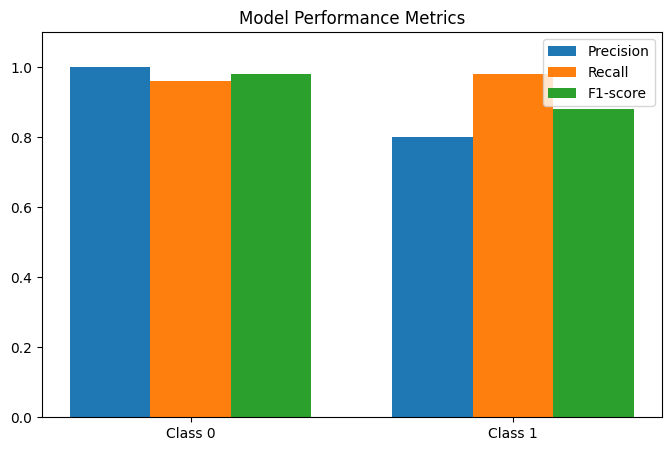

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Values from your report
labels = ['Class 0', 'Class 1']

precision = [1.00, 0.80]
recall = [0.96, 0.98]
f1_score = [0.98, 0.88]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-score')

plt.xticks(x, labels)
plt.ylim(0, 1.1)
plt.title('Model Performance Metrics')
plt.legend()

plt.show()

In [124]:
import numpy as np

print("Min:", np.min(y_prob))
print("Max:", np.max(y_prob))
print("Mean:", np.mean(y_prob))

Min: 0.0011524918
Max: 0.999592
Mean: 0.16983038
